In [ ]:
!git clone https://github.com/Herutriana44/sentiment-analysis-board-of-pieces

Cloning into 'sentiment-analysis-board-of-pieces'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 37 (delta 8), reused 34 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 359.06 KiB | 6.90 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [ ]:
%cd sentiment-analysis-board-of-pieces

/content/sentiment-analysis-board-of-pieces/sentiment-analysis-board-of-pieces


In [ ]:
!pip install -r requirements.txt -q

In [ ]:
import os
import re
import sys
import warnings

import emoji
import nltk
import numpy as np
import pandas as pd
import torch
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm
from transformers import BertForSequenceClassification, BertTokenizer
# =====================================================================
# CONFIGURATION & EXPORT SETUP
# =====================================================================
OUTPUT_FOLDER = "hasil_ekspor"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Class untuk menduplikasi print agar tampil di terminal SEKALIGUS tersimpan di file
class Logger(object):
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "w", encoding="utf-8")

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)

    def flush(self):
        self.terminal.flush()
        self.log.flush()

# Mulai mengalihkan output print ke file text di dalam folder hasil
sys.stdout = Logger(os.path.join(OUTPUT_FOLDER, "output_log.txt"))

warnings.filterwarnings("ignore", category=UserWarning)

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)


True

In [ ]:
BERT_LABELS = ["positif", "netral", "negatif"]
MODEL_NAME = "ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
bert_model = BertForSequenceClassification.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()

print("Device:", device)

tokenizer_config.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/230k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/476k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def preprocess_text(text):
    if pd.isna(text) or not str(text).strip():
        return ""
    text = str(text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"\@\w+|\#", "", text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    stop_words_en = set(stopwords.words("english"))
    stop_words_id = set(stopwords.words("indonesian"))
    text_tokens = word_tokenize(text)
    text = [
        word
        for word in text_tokens
        if word.lower() not in stop_words_en and word.lower() not in stop_words_id
    ]
    stemmer = PorterStemmer()
    text = [stemmer.stem(word) for word in text]
    lemmatizer = WordNetLemmatizer()
    text = [lemmatizer.lemmatize(word) for word in text]
    return " ".join(text)

In [ ]:
DATA_PATH = "BoP_Indonesia_Scraped_Data.xlsx"
TEXT_COLUMN = "full_text"

try:
    if DATA_PATH.lower().endswith((".xlsx", ".xls")):
        df = pd.read_excel(DATA_PATH)
    else:
        df = pd.read_csv(DATA_PATH)
    df = df[[TEXT_COLUMN]].copy()
    df = df.rename(columns={TEXT_COLUMN: "full_text"})
except FileNotFoundError:
    print("File tidak ditemukan — memakai contoh kecil untuk demonstrasi.")
    df = pd.DataFrame(
        {
            "full_text": [
                "Polri harus lebih transparan dalam komunikasi publik.",
                "Kinerja polisi di daerah saya sudah membaik, terima kasih.",
                "Kecewa dengan penanganan kasus yang lambat.",
                "Netral saja, perlu bukti lebih lanjut.",
                "Dukung reformasi institusi kepolisian.",
                "Pelayanan di satpas ramah dan cepat.",
                "Korupsi harus ditindak tegas tanpa pandang bulu.",
                "Pelayanan buruk sekali!",
            ]
        }
    )

df = df.dropna(subset=["full_text"]).reset_index(drop=True)
df["clean_text"] = df["full_text"].apply(preprocess_text)
df.loc[df["clean_text"].str.len() == 0, "clean_text"] = "[empty]"

In [ ]:
def predict_bert_label(text: str) -> str:
    enc = tokenizer(
        text,
        add_special_tokens=True,
        max_length=512,
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        outputs = bert_model(**enc)
        pred = torch.argmax(outputs.logits, dim=1).item()
    return BERT_LABELS[pred]

outputs = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="BERT autolabel", file=sys.stderr):
    try:
        outputs.append(predict_bert_label(row["clean_text"]))
    except Exception as e:
        print("Error pada teks:", row["clean_text"][:200], e)
        outputs.append("netral")

df["label"] = outputs


BERT autolabel:   0%|          | 0/908 [00:00<?, ?it/s]

In [ ]:
# --- EKSPOR 1: Menyimpan data hasil auto-labeling BERT ---
df.to_excel(os.path.join(OUTPUT_FOLDER, "data_hasil_label.xlsx"), index=False)

DROP_NETRAL = True

if DROP_NETRAL:
    df_nb = df[df["label"] != "netral"].copy().reset_index(drop=True)
else:
    df_nb = df.copy()

print("Jumlah baris untuk Naive Bayes:", len(df_nb))


In [ ]:
X = df_nb["clean_text"].astype(str)
y_raw = df_nb["label"].astype(str)

le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Kelas (encoded):", list(le.classes_))

if len(le.classes_) < 2:
    raise ValueError(
        "Hanya satu kelas tersisa. Set DROP_NETRAL=False atau tambah data agar ada minimal 2 kelas."
    )


In [ ]:
counts = np.bincount(y)
stratify_arg = y if counts.min() >= 2 and len(y) >= 6 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)

In [ ]:
param_grid_full = {
    "vec__ngram_range": [(1, 1), (1, 2)],
    "vec__min_df": [1, 2],
    "clf__alpha": [1e-3, 1e-2, 0.1, 0.5, 1.0, 2.0],
    "clf__fit_prior": [True, False],
}
param_grid_small = {
    "vec__ngram_range": [(1, 1)],
    "vec__min_df": [1],
    "clf__alpha": [0.01, 0.1, 1.0],
    "clf__fit_prior": [True],
}
param_grid = param_grid_small if len(X_train) < 15 else param_grid_full

cv_folds = 5
if len(X_train) < cv_folds * 2:
    cv_folds = max(2, len(X_train) // 2)

scoring = "f1_macro"

pipe_bow = Pipeline([("vec", CountVectorizer()), ("clf", MultinomialNB())])
pipe_tfidf = Pipeline([("vec", TfidfVectorizer()), ("clf", MultinomialNB())])

grid_bow = GridSearchCV(pipe_bow, param_grid, cv=cv_folds, scoring=scoring, n_jobs=-1, verbose=1)
grid_tfidf = GridSearchCV(pipe_tfidf, param_grid, cv=cv_folds, scoring=scoring, n_jobs=-1, verbose=1)

grid_bow.fit(X_train, y_train)
grid_tfidf.fit(X_train, y_train)

print("BoW   — best score (CV):", grid_bow.best_score_)
print("BoW   — best params:", grid_bow.best_params_)
print("TF-IDF — best score (CV):", grid_tfidf.best_score_)
print("TF-IDF — best params:", grid_tfidf.best_params_)

In [ ]:
best_bow = grid_bow.best_estimator_
best_tfidf = grid_tfidf.best_estimator_

y_pred_bow = best_bow.predict(X_test)
y_pred_tfidf = best_tfidf.predict(X_test)

target_names = le.classes_

summary = pd.DataFrame(
    {
        "Metode": ["BoW + MultinomialNB", "TF-IDF + MultinomialNB"],
        "Akurasi": [
            accuracy_score(y_test, y_pred_bow),
            accuracy_score(y_test, y_pred_tfidf),
        ],
        "F1 macro": [
            f1_score(y_test, y_pred_bow, average="macro"),
            f1_score(y_test, y_pred_tfidf, average="macro"),
        ],
    }
)


In [ ]:
# --- EKSPOR 2: Menyimpan tabel summary ke file Excel terpisah ---
summary.to_excel(os.path.join(OUTPUT_FOLDER, "ringkasan_performa.xlsx"), index=False)

print("\n=== BoW (test) ===")
print(classification_report(y_test, y_pred_bow, target_names=target_names))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_bow))

print("\n=== TF-IDF (test) ===")
print(classification_report(y_test, y_pred_tfidf, target_names=target_names))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_tfidf))

print(f"\n[INFO] Semua log dan hasil ekspor berhasil disimpan di folder: '{OUTPUT_FOLDER}'")

## Exploratory Data Analysis (EDA) Visualizations

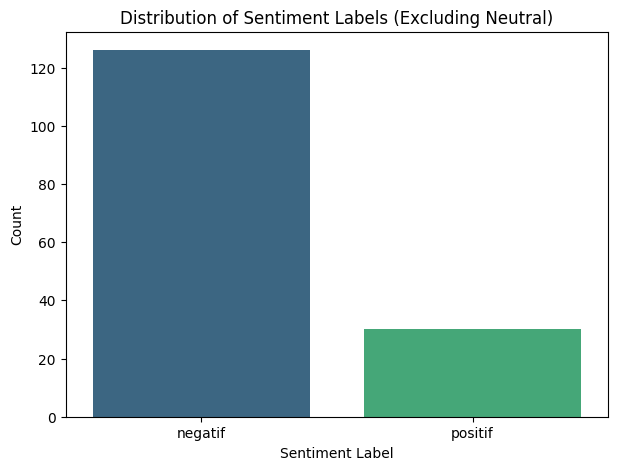

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of sentiment labels
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df_nb, palette='viridis', hue='label', legend=False)
plt.title('Distribution of Sentiment Labels (Excluding Neutral)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

## Model Performance Visualization

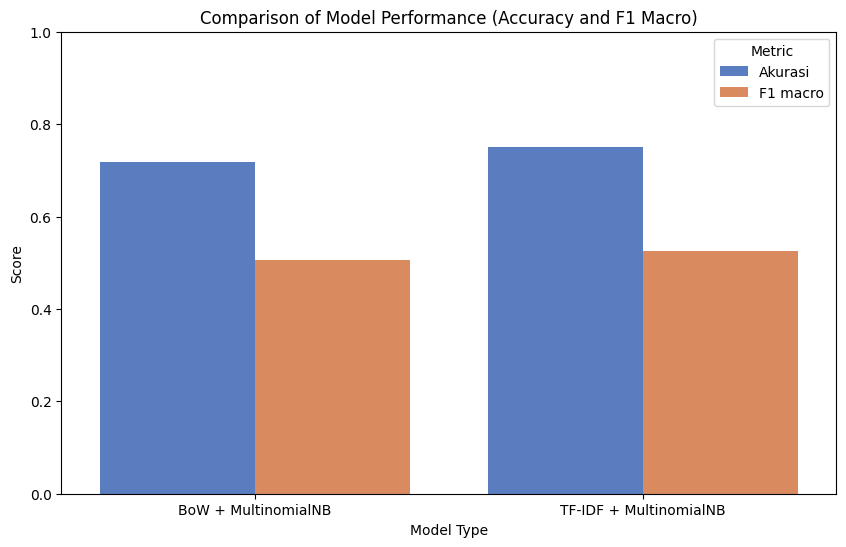

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize model performance metrics
summary_melted = summary.melt(id_vars=['Metode'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metode', y='Score', hue='Metric', data=summary_melted, palette='muted')
plt.title('Comparison of Model Performance (Accuracy and F1 Macro)')
plt.xlabel('Model Type')
plt.ylabel('Score')
plt.ylim(0, 1) # Scores are between 0 and 1
plt.legend(title='Metric')
plt.show()

## Word Cloud Visualization

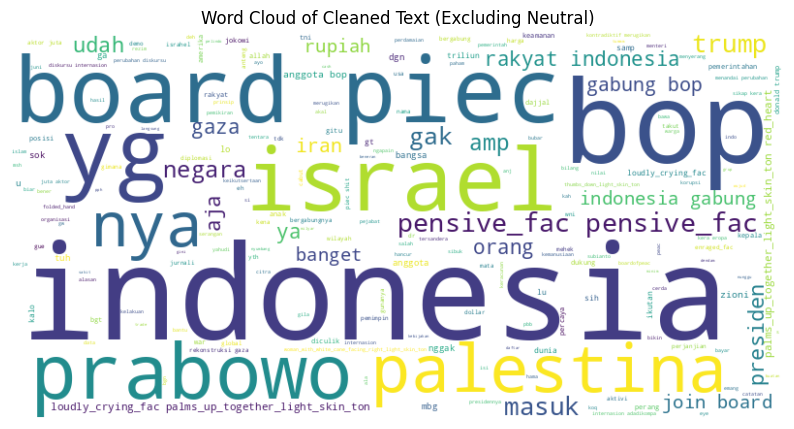

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string
all_text = ' '.join(df_nb['clean_text'].astype(str))

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the generated image:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Text (Excluding Neutral)')
plt.show()

## Word Clouds for Each Sentiment Label

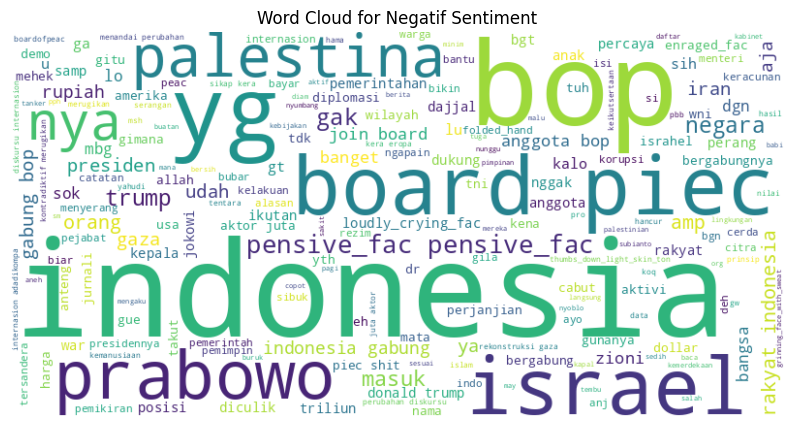

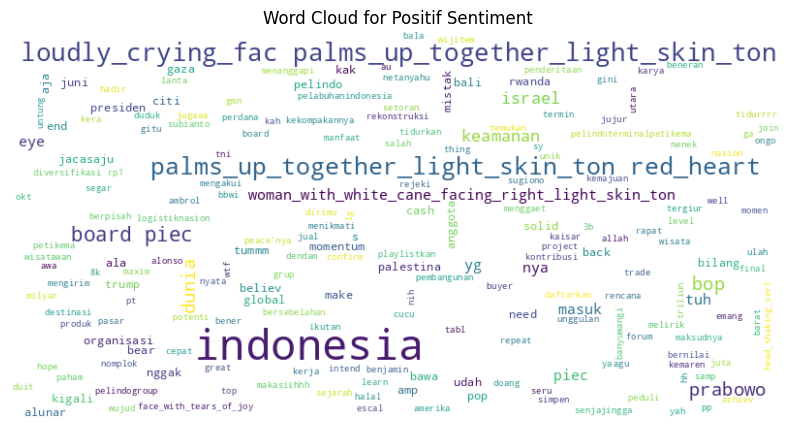

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

unique_labels = df_nb['label'].unique()

for label in unique_labels:
    # Filter DataFrame for the current label
    text_for_label = ' '.join(df_nb[df_nb['label'] == label]['clean_text'].astype(str))

    # Generate a word cloud image
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_for_label)

    # Display the generated image:
    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {label.capitalize()} Sentiment')
    plt.show()